## Simple Steam prices prediction
* [Dataset](https://www.kaggle.com/datasets/artyomkruglov/gaming-profiles-2025-steam-playstation-xbox):  archive/steam/\[ games.csv, prices.csv \] -> ./dataset/\[ games.csv, prices.csv \]

In [1]:
from ast import literal_eval

from tqdm.notebook import tqdm

import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

### Settings

In [2]:
available_currencies = ["usd", "eur", "gbp", "jpy", "rub"]
picked_cur = available_currencies[0]
max_price = 100

picked_cur, max_price

('usd', 100)

### Dataset work

In [3]:
games = pd.read_csv("./dataset/games.csv")
prices = pd.read_csv("./dataset/prices.csv")

In [4]:
print(games.size)
games.head(10)

687736


,gameid,title,developers,publishers,genres,supported_languages,release_date
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,2024-10-21
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,2024-10-17
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,2024-10-13
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN,2024-10-13
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN,2024-10-12
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",2024-10-11
6,3277430,Objective: F.E.A.S.T. Playtest,NaN,NaN,NaN,NaN,2024-10-12
7,3276500,Fortune Avenue Playtest,NaN,NaN,NaN,NaN,2024-10-09
8,3274370,Beyond the Ordinary Playtest,NaN,NaN,NaN,NaN,2024-10-11
9,3274670,Quantum Joe Playtest,NaN,NaN,NaN,NaN,2024-10-11


In [5]:
merged = pd.merge(games, prices, on=['gameid'], how='inner')

In [6]:
merged = merged.dropna(subset=['release_date', picked_cur])

In [7]:
merged.title.str.lower().str.contains("playtest").any()

False

In [8]:
merged = merged[merged[picked_cur] <= max_price]

In [9]:
merged = merged.sort_values(['title', 'date_acquired']).reset_index(drop=True)

In [10]:
merged['release_date'] = pd.to_datetime(merged['release_date'], errors='coerce')
merged['date_acquired'] = pd.to_datetime(merged['date_acquired'], errors='coerce')
merged = merged.reset_index()

In [11]:
print(merged.size)
merged.head()

48905668


,index,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,eur,gbp,jpy,rub,date_acquired
0,0,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-11-28
1,1,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-11-30
2,2,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-02
3,3,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-04
4,4,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-06


In [12]:
# merged['genres'] = merged['genres'].fillna("[]").apply(literal_eval)
# merged['developers'] = merged['developers'].fillna("[]").apply(literal_eval)
# merged['publishers'] = merged['publishers'].fillna("[]").apply(literal_eval)

In [13]:
# max_time = merged[['release_date', 'date_acquired']].max().max()

merged['days_since_release'] = (merged['date_acquired'] - merged['release_date']).dt.days

In [14]:
merged.head()

,index,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,eur,gbp,jpy,rub,date_acquired,days_since_release
0,0,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-11-28,4340
1,1,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-11-30,4342
2,2,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-02,4344
3,3,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-04,4346
4,4,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013-01-10,9.99,NaN,6.99,980.0,249.0,2024-12-06,4348


In [15]:
def transform_to_id(df, name) -> tuple[pd.Series, dict, list]:
    s = df[name]

    unique = s.explode().unique()
    vocab = { n: i for i, n in enumerate(unique) }

    s = s.map(lambda x: [vocab[y] for y in x])

    return s, vocab, unique

In [16]:
# genres_id, genres_vocab, _ = transform_to_id(merged, 'genres')

In [17]:
# devs_id, devs_vocab, _ = transform_to_id(merged, 'developers')

In [18]:
# pubs_id, pubs_vocab, _ = transform_to_id(merged, 'publishers')

In [19]:
# merged['genres'] = genres_id
# merged['developers'] = devs_id
# merged['publishers'] = pubs_id

In [20]:
merged['year'] = merged['date_acquired'].dt.year
merged['month'] = merged['date_acquired'].dt.month
merged['dayofweek'] = merged['date_acquired'].dt.dayofweek

In [21]:
merged['release_date'] = merged['release_date'].dt.year

In [22]:
merged['month_sin'] = np.sin(2 * np.pi * merged['month'] / 12)
merged['month_cos'] = np.cos(2 * np.pi * merged['month'] / 12)
merged['dow_sin'] = np.sin(2 * np.pi * merged['dayofweek'] / 7)
merged['dow_cos'] = np.cos(2 * np.pi * merged['dayofweek'] / 7)

In [23]:
merged = merged.drop(set(available_currencies).difference([picked_cur]), axis=1)

In [24]:
merged1 = merged.copy()

In [25]:
merged

,index,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,year,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos
0,0,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-28,4340,2024,11,3,-5.000000e-01,0.866025,0.433884,-0.900969
1,1,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-30,4342,2024,11,5,-5.000000e-01,0.866025,-0.974928,-0.222521
2,2,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-02,4344,2024,12,0,-2.449294e-16,1.000000,0.000000,1.000000
3,3,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-04,4346,2024,12,2,-2.449294e-16,1.000000,0.974928,-0.222521
4,4,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-06,4348,2024,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493257,3493257,1116910,NaN,NaN,NaN,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...",NaN,2019,6.99,2025-02-16,1971,2025,2,6,8.660254e-01,0.500000,-0.781831,0.623490
3493258,3493258,1116910,NaN,NaN,NaN,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...",NaN,2019,6.99,2025-02-18,1973,2025,2,1,8.660254e-01,0.500000,0.781831,0.623490
3493259,3493259,1116910,NaN,NaN,NaN,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...",NaN,2019,6.99,2025-02-20,1975,2025,2,3,8.660254e-01,0.500000,0.433884,-0.900969
3493260,3493260,1116910,NaN,NaN,NaN,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...",NaN,2019,6.99,2025-02-22,1977,2025,2,5,8.660254e-01,0.500000,-0.974928,-0.222521


In [26]:
def create_time_features_lag(group):
    group = group.copy()
    # Лаги
    earliest = group['usd'].iloc[0] 
    group['lag_1_price'] = group['usd'].shift(1).fillna(earliest)
    group['lag_2_price'] = group['usd'].shift(2).fillna(earliest)
    return group

In [27]:
merged = merged.groupby('title').apply(create_time_features_lag)

merged

D:\Users\foler\AppData\Local\Temp\ipykernel_7120\631786675.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged = merged.groupby('title').apply(create_time_features_lag)


index   gameid            title  \
title                                                        
 Fieldrunners 2 0              0   215710   Fieldrunners 2   
                1              1   215710   Fieldrunners 2   
                2              2   215710   Fieldrunners 2   
                3              3   215710   Fieldrunners 2   
                4              4   215710   Fieldrunners 2   
...                          ...      ...              ...   
𣸩               3493212  3493212  2639280                𣸩   
                3493213  3493213  2639280                𣸩   
                3493214  3493214  2639280                𣸩   
                3493215  3493215  2639280                𣸩   
                3493216  3493216  2639280                𣸩   

                                        developers                 publishers  \
title                                                                           
 Fieldrunners 2 0        ['Subatomic Studios LLC']  ['Subatomic Studios LLC']   
                1        ['Subatomic Studios LLC']  ['Subatomic Studios LLC']   
                2        ['Subatomic Studios LLC']  ['Subatomic Studios LLC']   
                3        ['Subatomic Studios LLC']  ['Subatomic Studios LLC']   
                4        ['Subatomic Studios LLC']  ['Subatomic Studios LLC']   
...                                            ...                        ...   
𣸩               3493212     ['箱崎奈绪(Hakozaki Nao)']    [' 箱崎奈绪(Hakozaki Nao)']   
                3493213     ['箱崎奈绪(Hakozaki Nao)']    [' 箱崎奈绪(Hakozaki Nao)']   
                3493214     ['箱崎奈绪(Hakozaki Nao)']    [' 箱崎奈绪(Hakozaki Nao)']   
                3493215     ['箱崎奈绪(Hakozaki Nao)']    [' 箱崎奈绪(Hakozaki Nao)']   
                3493216     ['箱崎奈绪(Hakozaki Nao)']    [' 箱崎奈绪(Hakozaki Nao)']   

                                                   genres  \
title                                                       
 Fieldrunners 2 0        ['Action', 'Strategy', 'Casual']   
                1        ['Action', 'Strategy', 'Casual']   
                2        ['Action', 'Strategy', 'Casual']   
                3        ['Action', 'Strategy', 'Casual']   
                4        ['Action', 'Strategy', 'Casual']   
...                                                   ...   
𣸩               3493212  ['Adventure', 'Casual', 'Indie']   
                3493213  ['Adventure', 'Casual', 'Indie']   
                3493214  ['Adventure', 'Casual', 'Indie']   
                3493215  ['Adventure', 'Casual', 'Indie']   
                3493216  ['Adventure', 'Casual', 'Indie']   

                                                   supported_languages  \
title                                                                    
 Fieldrunners 2 0                                          ['English']   
                1                                          ['English']   
                2                                          ['English']   
                3                                          ['English']   
                4                                          ['English']   
...                                                                ...   
𣸩               3493212  ['Simplified Chinese', 'Traditional Chinese']   
                3493213  ['Simplified Chinese', 'Traditional Chinese']   
                3493214  ['Simplified Chinese', 'Traditional Chinese']   
                3493215  ['Simplified Chinese', 'Traditional Chinese']   
                3493216  ['Simplified Chinese', 'Traditional Chinese']   

                         release_date   usd date_acquired  days_since_release  \
title                                                                           
 Fieldrunners 2 0                2013  9.99    2024-11-28                4340   
                1                2013  9.99    2024-11-30                4342   
                2                2013  9.99    2024-12-02                4344   
    

In [28]:
merged = merged.dropna().reset_index(drop=True)

merged

,index,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,days_since_release,year,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos,lag_1_price,lag_2_price
0,0,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-28,4340,2024,11,3,-5.000000e-01,0.866025,0.433884,-0.900969,9.99,9.99
1,1,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-30,4342,2024,11,5,-5.000000e-01,0.866025,-0.974928,-0.222521,9.99,9.99
2,2,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-02,4344,2024,12,0,-2.449294e-16,1.000000,0.000000,1.000000,9.99,9.99
3,3,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-04,4346,2024,12,2,-2.449294e-16,1.000000,0.974928,-0.222521,9.99,9.99
4,4,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-06,4348,2024,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969,9.99,9.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463171,3493212,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-16,415,2025,2,6,8.660254e-01,0.500000,-0.781831,0.623490,1.99,1.99
3463172,3493213,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-18,417,2025,2,1,8.660254e-01,0.500000,0.781831,0.623490,1.99,1.99
3463173,3493214,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-20,419,2025,2,3,8.660254e-01,0.500000,0.433884,-0.900969,1.99,1.99
3463174,3493215,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-22,421,2025,2,5,8.660254e-01,0.500000,-0.974928,-0.222521,1.99,1.99


In [29]:
merged2 = merged.copy()

# LightGBM

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

In [31]:
df_final = merged.copy()

In [32]:
enc_dict = {}
categorical_cols = ['title']  # Добавьте сюда все категориальные колонки
for col in categorical_cols:
    le = LabelEncoder()
    df_final[f'{col}_enc'] = le.fit_transform(merged[col])
    enc_dict[col] = le

# Обрабатываем столбцы со списками (глобальный энкодер для каждого)
list_cols = ['developers', 'publishers', 'genres', 'supported_languages']
for col in list_cols:
    # Применяем уникальный LabelEncoder к строковому представлению списка
    le = LabelEncoder()
    df_final[f'{col}_enc'] = le.fit_transform(merged[col].astype(str))
    enc_dict[col] = le

# Удаляем возможные пропуски, которые могли появиться из-за неполных данных
df_final = df_final.dropna()

In [33]:
df_final

,index,gameid,title,developers,publishers,genres,supported_languages,release_date,usd,date_acquired,...,month_cos,dow_sin,dow_cos,lag_1_price,lag_2_price,title_enc,developers_enc,publishers_enc,genres_enc,supported_languages_enc
0,0,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-28,...,0.866025,0.433884,-0.900969,9.99,9.99,0,36831,32551,553,12336
1,1,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-11-30,...,0.866025,-0.974928,-0.222521,9.99,9.99,0,36831,32551,553,12336
2,2,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-02,...,1.000000,0.000000,1.000000,9.99,9.99,0,36831,32551,553,12336
3,3,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-04,...,1.000000,0.974928,-0.222521,9.99,9.99,0,36831,32551,553,12336
4,4,215710,Fieldrunners 2,['Subatomic Studios LLC'],['Subatomic Studios LLC'],"['Action', 'Strategy', 'Casual']",['English'],2013,9.99,2024-12-06,...,1.000000,-0.433884,-0.900969,9.99,9.99,0,36831,32551,553,12336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463171,3493212,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-16,...,0.500000,-0.781831,0.623490,1.99,1.99,77003,47171,613,635,12795
3463172,3493213,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-18,...,0.500000,0.781831,0.623490,1.99,1.99,77003,47171,613,635,12795
3463173,3493214,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-20,...,0.500000,0.433884,-0.900969,1.99,1.99,77003,47171,613,635,12795
3463174,3493215,2639280,𣸩,['箱崎奈绪(Hakozaki Nao)'],[' 箱崎奈绪(Hakozaki Nao)'],"['Adventure', 'Casual', 'Indie']","['Simplified Chinese', 'Traditional Chinese']",2023,1.99,2025-02-22,...,0.500000,-0.974928,-0.222521,1.99,1.99,77003,47171,613,635,12795


In [34]:
da = np.sort(merged['date_acquired'].unique())
test_start_date = da[int(len(da)*0.8)]
test_start_date

numpy.datetime64('2025-02-08T00:00:00.000000000')

In [35]:
da

array(['2024-11-28T00:00:00.000000000', '2024-11-30T00:00:00.000000000',
       '2024-12-02T00:00:00.000000000', '2024-12-04T00:00:00.000000000',
       '2024-12-06T00:00:00.000000000', '2024-12-08T00:00:00.000000000',
       '2024-12-10T00:00:00.000000000', '2024-12-12T00:00:00.000000000',
       '2024-12-14T00:00:00.000000000', '2024-12-16T00:00:00.000000000',
       '2024-12-18T00:00:00.000000000', '2024-12-20T00:00:00.000000000',
       '2024-12-22T00:00:00.000000000', '2024-12-24T00:00:00.000000000',
       '2024-12-26T00:00:00.000000000', '2024-12-28T00:00:00.000000000',
       '2024-12-30T00:00:00.000000000', '2025-01-01T00:00:00.000000000',
       '2025-01-03T00:00:00.000000000', '2025-01-05T00:00:00.000000000',
       '2025-01-07T00:00:00.000000000', '2025-01-09T00:00:00.000000000',
       '2025-01-11T00:00:00.000000000', '2025-01-13T00:00:00.000000000',
       '2025-01-15T00:00:00.000000000', '2025-01-17T00:00:00.000000000',
       '2025-01-19T00:00:00.000000000', '2025-01-21

In [36]:
train_mask = merged['date_acquired'] < test_start_date
test_mask = merged['date_acquired'] >= test_start_date

df_train = df_final[train_mask]
df_test = df_final[test_mask]

In [37]:
def create_time_features_roll(group):
    group = group.copy()
    # Скользящее среднее за 3 и 5 периодов
    group['rolling_mean_3'] = group['usd'].rolling(window=3, min_periods=1).mean()
    group['rolling_mean_5'] = group['usd'].rolling(window=5, min_periods=1).mean()
    return group

In [38]:
# df_train = df_train.groupby('title').apply(create_time_features_roll)
# df_test = df_test.groupby('title').apply(create_time_features_roll)

# df_train = df_train.dropna().reset_index(drop=True)
# df_test = df_test.dropna().reset_index(drop=True)

In [41]:
feature_cols = [
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'days_since_release', 
    # 'lag_1_price', 'lag_2_price', 
    # 'rolling_mean_3', 'rolling_mean_5',
    'title_enc', 'developers_enc', 'publishers_enc', 'genres_enc', 'supported_languages_enc'
]

X_train = df_train[feature_cols].copy()
y_train = df_train[picked_cur]

X_test = df_test[feature_cols].copy()
y_test = df_test[picked_cur]

In [42]:
len(df_final), len(X_train) + len(X_test), len(X_train), len(X_test)

(3463176, 3463176, 2770721, 692455)

In [43]:
categorical_features = [f'{col}_enc' for col in categorical_cols + list_cols]
categorical_features

['title_enc',
 'developers_enc',
 'publishers_enc',
 'genres_enc',
 'supported_languages_enc']

In [44]:
lgb_model = lgb.LGBMRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7
)

In [45]:
lgb_model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_features
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 97837
[LightGBM] [Info] Number of data points in the train set: 2770721, number of used features: 10
[LightGBM] [Info] Start training from score 7.450706


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
y_pred = lgb_model.predict(X_test)

In [47]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"MAE: {mae:.2f} USD")
print(f"RMSE: {rmse:.2f} USD")

MAE: 4.21 USD
RMSE: 5.64 USD


In [48]:
feature_importances = pd.DataFrame({
    'feature': lgb_model.feature_name_,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

                   feature  importance
4       days_since_release        3409
0                month_sin        2346
6           developers_enc        2065
7           publishers_enc        1974
8               genres_enc        1698
5                title_enc        1592
9  supported_languages_enc        1278
2                  dow_sin         591
3                  dow_cos          40
1                month_cos           7


In [50]:
y_true = y_test

# LTSM
Bad results ;)

In [ ]:
SEQUENCE_LENGTH = 4
FEATURE_COLS = ['days_since_release', 'month_sin','month_cos','dow_sin','dow_cos']
L =  len(FEATURE_COLS)

In [ ]:
def create_sequences_for_game(game_df, sequence_length=SEQUENCE_LENGTH, feature_cols=FEATURE_COLS, target_col=picked_cur):
    """
    Для одной игры (отсортированной по дате) создаёт окна.
    Возвращает:
        X_seq: список окон (L x num_features)
        X_static: список статических признаков (одинаков для всех окон игры)
        y: целевые значения (цена на следующий шаг)
        также списки IDs для категорий
    """
    if len(game_df) < sequence_length + 1:
        return [[]]*6
    
    dev_ids = game_df.iloc[0]['developers']
    pub_ids = game_df.iloc[0]['publishers']
    gen_ids = game_df.iloc[0]['genres']
    release_year = game_df.iloc[0]['release_date']
    
    X_seq = []
    y = []
    # список окон будем собирать
    for i in range(len(game_df) - sequence_length):
        # берём L записей как вход
        window = game_df.iloc[i:i+sequence_length][feature_cols].values  # shape (SL, num_features)
        target = game_df.iloc[i+sequence_length][target_col]
        X_seq.append(window)
        y.append(target)
    
    # статические данные повторяются для каждого окна
    static_dev = [dev_ids] * len(X_seq)
    static_pub = [pub_ids] * len(X_seq)
    static_gen = [gen_ids] * len(X_seq)
    static_release_year = [release_year] * len(X_seq)
    
    return X_seq, y, static_dev, static_pub, static_gen, static_release_year

In [ ]:
gameids = merged['gameid'].unique()

In [ ]:
selected_gameids = pd.Series(gameids).sample(frac=0.1, random_state=42)

In [ ]:
sampled = merged[merged['gameid'].isin(selected_gameids)]

In [ ]:
all_X_seq = []
all_y = []
all_dev = []
all_pub = []
all_gen = []
all_release_year = []

for gameid, group in tqdm(sampled.groupby('gameid')):
    # группировка уже отсортирована
    res = create_sequences_for_game(group, SEQUENCE_LENGTH)
    X_seq, y, dev, pub, gen, rel_year = res
    if len(X_seq) > 0:
        all_X_seq.extend(X_seq)
        all_y.extend(y)
        all_dev.extend(dev)
        all_pub.extend(pub)
        all_gen.extend(gen)
        all_release_year.extend(rel_year)

X_seq = np.array(all_X_seq)
y = np.array(all_y)

  0%|          | 0/7822 [00:00<?, ?it/s]

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.layers import Input, LSTM, Concatenate, Dense, Embedding, GlobalAveragePooling1D, Dropout
from keras.models import Model

In [ ]:
num_features = X_seq.shape[2]
# Создаём один scaler на все числовые признаки (обучаем на всём X_seq)
scaler = MinMaxScaler(feature_range=(0, 1))
# Нужно привести X_seq к 2D для fit (n_samples*SL, num_features)
original_shape = X_seq.shape
X_seq_flat = X_seq.reshape(-1, num_features)
scaler.fit(X_seq_flat)
X_seq_scaled = scaler.transform(X_seq_flat).reshape(original_shape)

# ============================================
# 6. Подготовка категориальных последовательностей (паддинг)
# ============================================
# Для каждого списка IDs используем паддинг до максимальной длины в датасете
max_dev_len = max(len(lst) for lst in all_dev)
max_pub_len = max(len(lst) for lst in all_pub)
max_gen_len = max(len(lst) for lst in all_gen)

def pad_ids(ids_list, max_len):
    return np.array([lst + [0]*(max_len - len(lst)) for lst in ids_list])

dev_padded = pad_ids(all_dev, max_dev_len)
pub_padded = pad_ids(all_pub, max_pub_len)
gen_padded = pad_ids(all_gen, max_gen_len)

release_year_arr = np.array(all_release_year).reshape(-1, 1)

static_scaler = MinMaxScaler()
release_year_scaled = static_scaler.fit_transform(release_year_arr)

In [ ]:
split_idx = int(len(X_seq_scaled) * 0.8)
X_train_seq = X_seq_scaled[:split_idx]
X_test_seq = X_seq_scaled[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

dev_train = dev_padded[:split_idx]
dev_test = dev_padded[split_idx:]
pub_train = pub_padded[:split_idx]
pub_test = pub_padded[split_idx:]
gen_train = gen_padded[:split_idx]
gen_test = gen_padded[split_idx:]
rel_train = release_year_scaled[:split_idx]
rel_test = release_year_scaled[split_idx:]

In [ ]:
def embedding_layer(vocab: dict, output_dim: int = 8, name: str=None) -> tuple:
    inp = Input(shape=(None,), name=f"{name}_in")
    emb = Embedding(input_dim=len(vocab) + 1, output_dim=output_dim, name=f"{name}_emb")(inp)
    pool = GlobalAveragePooling1D(name=f"{name}_pool")(emb)
    return inp, pool

In [ ]:
seq_input = x = Input(shape=(SEQUENCE_LENGTH, L), name="seq_input")
lstm_outs = []
for neurons in [256, 128, 64]:
    lstm_out = LSTM(neurons, return_sequences=False, dropout=0.2, recurrent_dropout=0.2, name=f"lstm_{neurons}")(seq_input)
    lstm_outs.append(lstm_out) 

In [ ]:
dev_in, dev_out = embedding_layer(devs_vocab, name="dev")
pub_in, pub_out = embedding_layer(pubs_vocab, name="pub")
genres_in, genres_out = embedding_layer(genres_vocab, name="genres")

In [ ]:
rel_year_in = Input((1,), name="rel_year_in")

In [ ]:
x = Concatenate(name="concat_all")([
    *lstm_outs,
    dev_out,
    pub_out,
    genres_out,
    rel_year_in,
])

x = Dense(32, activation='gelu', name="dense_1")(x)
x = Dropout(0.3, name="drop")(x)
x = Dense(16, activation='relu', name="dense_2")(x)
x = Dense(1, activation='linear', name="usd")(x)

model = Model(inputs=[
    seq_input,
    dev_in, pub_in, genres_in,
    rel_year_in,
], outputs=x)

In [ ]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dev_in (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pub_in (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genres_in           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 4, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dev_emb (Embedding) │ (None, None, 8)   │    398,272 │ dev_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pub_emb (Embedding) │ (None, None, 8)   │    335,736 │ pub_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genres_emb          │ (None, None, 8)   │        280 │ genres_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_256 (LSTM)     │ (None, 256)       │    268,288 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_128 (LSTM)     │ (None, 128)       │     68,608 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_64 (LSTM)      │ (None, 64)        │     17,920 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dev_pool            │ (None, 8)         │          0 │ dev_emb[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pub_pool            │ (None, 8)         │          0 │ pub_emb[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genres_pool         │ (None, 8)         │          0 │ genres_emb[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rel_year_in         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_all          │ (None, 473)       │          0 │ lstm_256[0][0],   │
│ (Concatenate)       │                   │            │ lstm_128[0][0],   │
│                     │                   │            │ lstm_64[0][0],    │
│                     │                   │            │ dev_pool[0][0],   │
│                     │                   │            │ pub_pool[0][0],   │
│                     │                   │            │ genres_pool[0][0… │
│                     │                   │            │ rel_year_in[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │     15,168 │ concat_all[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop (Dropout)      │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ drop[0][0]        │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,104,817 (4.21 MB)

 Trainable params: 1,104,817 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mse']
)

In [ ]:
x_train={
    "seq_input": X_train_seq, 
    "dev_in": dev_train, 
    "pub_in": pub_train, 
    "genres_in": gen_train, 
    "rel_year_in": rel_train
}

In [ ]:
list(map(lambda x: x.shape, x_train.values()))

[(254668, 4, 5), (254668, 7), (254668, 5), (254668, 10), (254668, 1)]

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
model.fit(
    x=x_train,
    y=y_train,
    batch_size=256,
    epochs=20,
    validation_data=((X_test_seq, dev_test, pub_test, gen_test, rel_test), y_test),
    callbacks=[early_stop, reduce_lr],
)

In [ ]:
x_test = {
    "seq_input": X_test_seq, 
    "dev_in": dev_test, 
    "pub_in": pub_test, 
    "genres_in": gen_test, 
    "rel_year_in": rel_test
}

In [ ]:
pred = model.predict(x_test, batch_size=512)

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


In [ ]:
list(zip(pred, y_test))

[(array([31.114824], dtype=float32), 29.99),
 (array([30.087086], dtype=float32), 29.99),
 (array([29.764194], dtype=float32), 29.99),
 (array([29.628174], dtype=float32), 29.99),
 (array([26.90278], dtype=float32), 29.99),
 (array([26.266861], dtype=float32), 29.99),
 (array([26.194519], dtype=float32), 29.99),
 (array([26.398834], dtype=float32), 29.99),
 (array([26.678204], dtype=float32), 29.99),
 (array([26.83123], dtype=float32), 29.99),
 (array([26.472183], dtype=float32), 29.99),
 (array([26.460522], dtype=float32), 29.99),
 (array([26.83698], dtype=float32), 29.99),
 (array([26.646063], dtype=float32), 29.99),
 (array([26.373962], dtype=float32), 29.99),
 (array([26.654118], dtype=float32), 29.99),
 (array([26.807598], dtype=float32), 29.99),
 (array([26.447565], dtype=float32), 29.99),
 (array([26.435879], dtype=float32), 29.99),
 (array([30.011936], dtype=float32), 29.99),
 (array([30.411833], dtype=float32), 29.99),
 (array([30.16071], dtype=float32), 29.99),
 (array([29.85

<Axes: xlabel='date_acquired'>

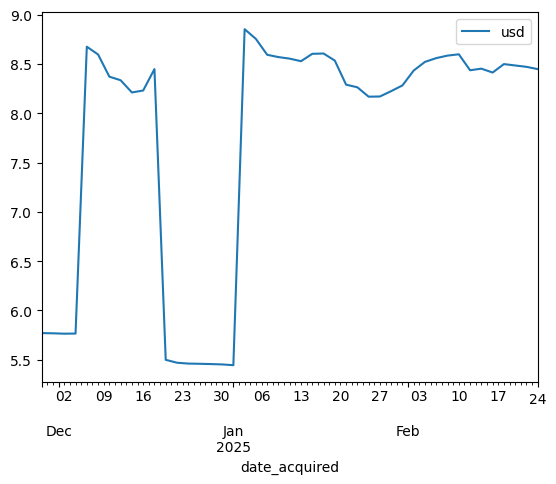

In [ ]:
sampled[['usd', 'date_acquired', ]].groupby('date_acquired').mean().plot()

In [ ]:
y_train_pred = model.predict((X_train_seq, dev_train, pub_train, gen_train, rel_train), batch_size=512)

498/498 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


In [ ]:
list(zip(y_train_pred, y_train))

[(array([24.286129], dtype=float32), 9.99),
 (array([24.483301], dtype=float32), 9.99),
 (array([24.48307], dtype=float32), 9.99),
 (array([24.287613], dtype=float32), 9.99),
 (array([24.380024], dtype=float32), 1.99),
 (array([24.55076], dtype=float32), 1.99),
 (array([21.415287], dtype=float32), 1.99),
 (array([20.354652], dtype=float32), 1.99),
 (array([20.648445], dtype=float32), 1.99),
 (array([20.94636], dtype=float32), 1.99),
 (array([20.587997], dtype=float32), 1.99),
 (array([20.853226], dtype=float32), 9.99),
 (array([21.108562], dtype=float32), 9.99),
 (array([20.726284], dtype=float32), 9.99),
 (array([20.66232], dtype=float32), 9.99),
 (array([21.067684], dtype=float32), 9.99),
 (array([20.968401], dtype=float32), 9.99),
 (array([20.610626], dtype=float32), 9.99),
 (array([20.875374], dtype=float32), 1.99),
 (array([21.13036], dtype=float32), 1.99),
 (array([20.748695], dtype=float32), 1.99),
 (array([18.060434], dtype=float32), 1.99),
 (array([18.062284], dtype=float32), 

In [ ]:
X_train_seq[0]

array([[0.73954037, 0.73205081, 0.73205081, 0.27747907, 0.        ],
       [0.73924573, 0.73205081, 0.73205081, 1.        , 0.35689587],
       [0.73895109, 0.73205081, 0.73205081, 0.5       , 1.        ],
       [0.73865645, 0.73205081, 0.73205081, 0.        , 0.35689587]])

# Results

In [51]:
residuals = y_test - y_pred
diff = residuals.abs()

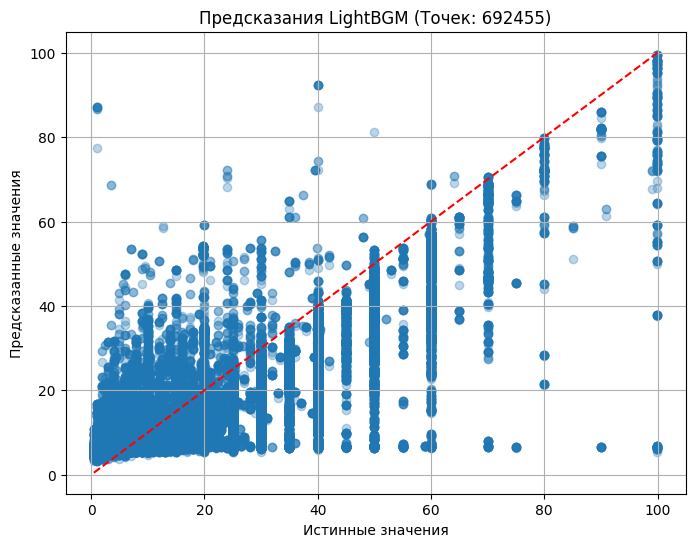

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания LightBGM (Точек: {len(y_pred)})')
plt.grid()
plt.show()

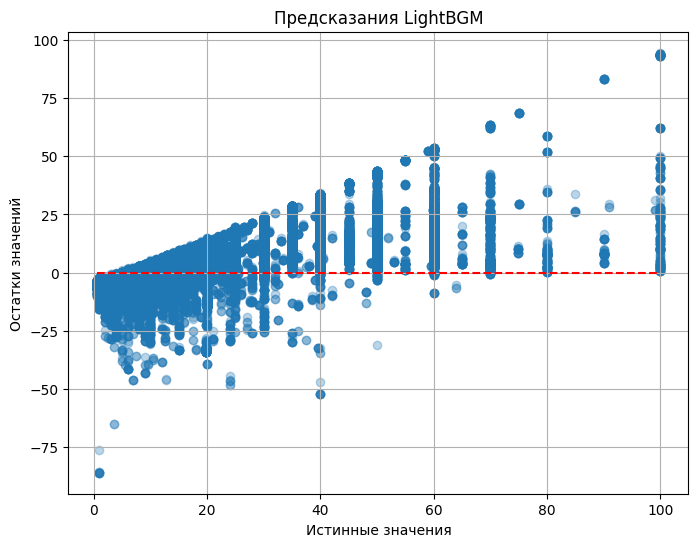

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(y_true, residuals, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [0, 0], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Остатки значений')
plt.title(f'Предсказания LightBGM')
plt.grid()
plt.show()

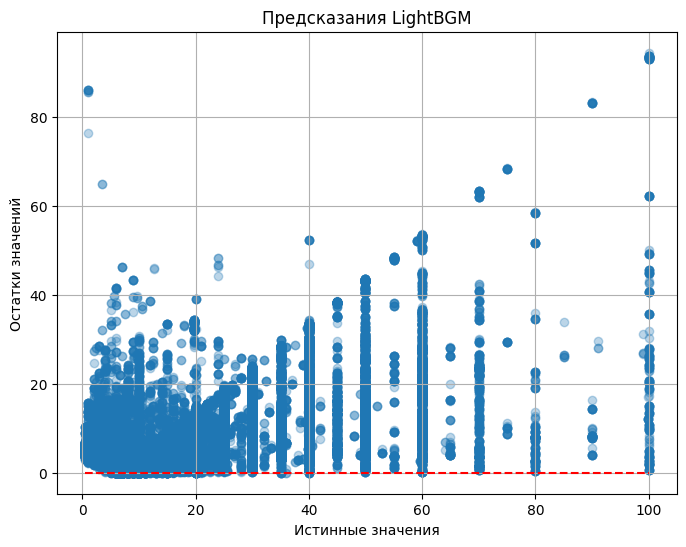

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(y_true, diff, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [0, 0], 'r--')
plt.xlabel('Истинные значения')
plt.ylabel('Остатки значений')
plt.title(f'Предсказания LightBGM')
plt.grid()
plt.show()

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
r2 = r2_score(y_true, y_pred)
r2

0.588585175893743

Text(0.5, 1.0, 'Гистограмма остатков')

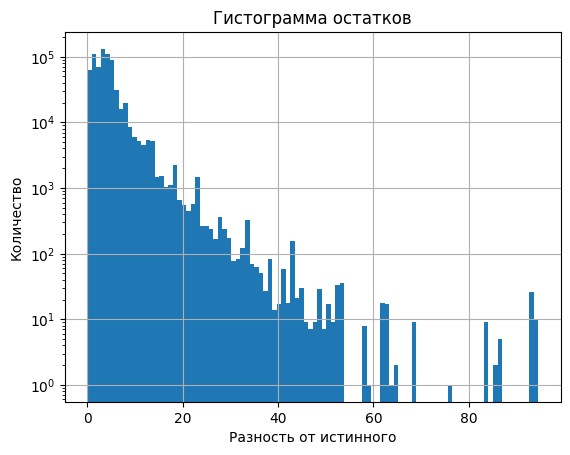

In [57]:
diff.hist(bins=100, log=True)
plt.xlabel('Разность от истинного')
plt.ylabel('Количество')
plt.title('Гистограмма остатков')

In [58]:
import statsmodels.api as sm

<Figure size 600x600 with 0 Axes>

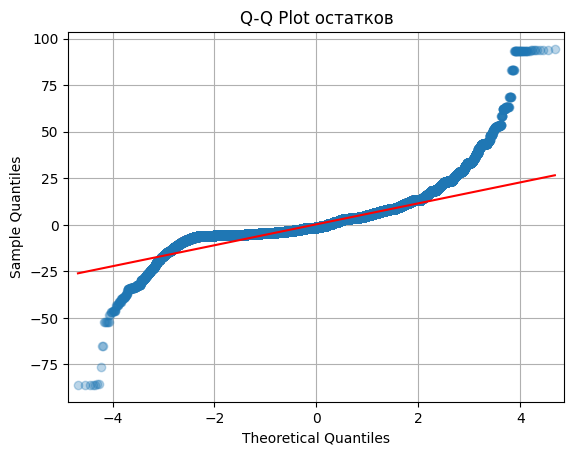

In [59]:
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='s', alpha=0.3)
plt.title('Q-Q Plot остатков')
plt.grid()
plt.show()

In [60]:
import scipy.stats as stats 

In [61]:
stats.normaltest(residuals), stats.wilcoxon(residuals), stats.shapiro(residuals)

d:\Program Files\GitHub\CompMath2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 692455.
  res = hypotest_fun_out(*samples, **kwds)


(NormaltestResult(statistic=314302.92349648965, pvalue=0.0),
 WilcoxonResult(statistic=112172828591.0, pvalue=0.0),
 ShapiroResult(statistic=0.8610643045666723, pvalue=7.29696820967341e-160))

In [62]:
title_enc: LabelEncoder = enc_dict['title']

In [63]:
y_pred

array([7.07085141, 7.07085141, 7.0034938 , ..., 6.67244808, 6.67244808,
       6.67244808])

In [64]:
X_test.iloc[diff.argmax()-10:diff.argmax()+10]

,month_sin,month_cos,dow_sin,dow_cos,days_since_release,title_enc,developers_enc,publishers_enc,genres_enc,supported_languages_enc
768390,0.866025,0.5,0.000000,1.000000,88,17084,15030,13507,1062,12336
768391,0.866025,0.5,0.974928,-0.222521,90,17084,15030,13507,1062,12336
768392,0.866025,0.5,-0.433884,-0.900969,92,17084,15030,13507,1062,12336
768393,0.866025,0.5,-0.781831,0.623490,94,17084,15030,13507,1062,12336
768394,0.866025,0.5,0.781831,0.623490,96,17084,15030,13507,1062,12336
768395,0.866025,0.5,0.433884,-0.900969,98,17084,15030,13507,1062,12336
768396,0.866025,0.5,-0.974928,-0.222521,100,17084,15030,13507,1062,12336
768397,0.866025,0.5,0.000000,1.000000,102,17084,15030,13507,1062,12336
768434,0.866025,0.5,-0.974928,-0.222521,1107,17085,41795,36941,1014,12336
768435,0.866025,0.5,0.000000,1.000000,1109,17085,41795,36941,1014,12336


In [65]:
y_pred[diff.argmax()-10:diff.argmax()+10]

array([6.84736698, 6.78000938, 6.84736698, 6.84736698, 6.84736698,
       6.84736698, 6.84736698, 6.84736698, 6.17773567, 6.17773567,
       5.44911559, 6.17773567, 6.17773567, 6.17773567, 6.17773567,
       6.17773567, 6.17773567, 9.7359886 , 9.7359886 , 9.668631  ])

In [66]:
residuals[diff.argmax()-10:diff.argmax()+10]

768390     3.142633
768391     3.209991
768392     3.142633
768393     3.142633
768394     3.142633
768395     3.142633
768396     3.142633
768397     3.142633
768434    93.812264
768435    93.812264
768436    94.540884
768437    93.812264
768438    93.812264
768439    93.812264
768440    93.812264
768441    93.812264
768442    93.812264
768479     2.254011
768480     2.254011
768481     2.321369
Name: usd, dtype: float64

In [67]:
title_enc.inverse_transform([25272])[0]

'Gamitate - Meditate, Relax, Feel Better'

In [68]:
merged[merged['title'] == 'Gamitate - Meditate, Relax, Feel Better'][picked_cur][train_mask]

1136716    99.99
1136717    99.99
1136718    99.99
1136719    99.99
1136720    99.99
1136721    99.99
1136722    99.99
1136723    99.99
1136724    99.99
1136725    99.99
1136726    99.99
1136727    99.99
1136728    99.99
1136729    99.99
1136730    99.99
1136731    99.99
1136732    99.99
1136733    99.99
1136734    99.99
1136735    99.99
1136736    99.99
1136737    99.99
1136738    99.99
1136739    99.99
1136740    99.99
1136741    99.99
1136742    99.99
1136743    99.99
1136744    99.99
1136745    99.99
1136746    99.99
1136747    99.99
1136748    99.99
1136749    99.99
1136750    99.99
1136751    99.99
Name: usd, dtype: float64

In [69]:
mask_border = df_test['date_acquired'] == test_start_date

In [70]:
diff[mask_border]

36         2.919149
81         5.555041
126        0.142633
171        2.216126
216        8.695699
             ...   
3462987    3.773445
3463032    1.453119
3463077    4.532441
3463122    6.332173
3463167    4.682448
Name: usd, Length: 76949, dtype: float64

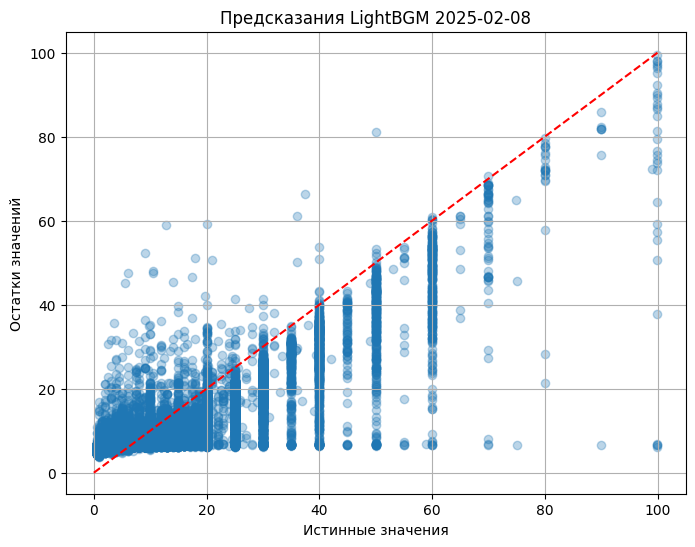

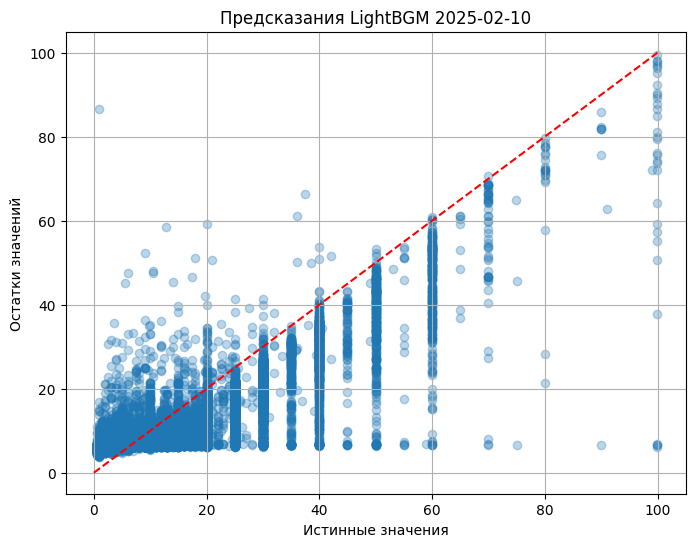

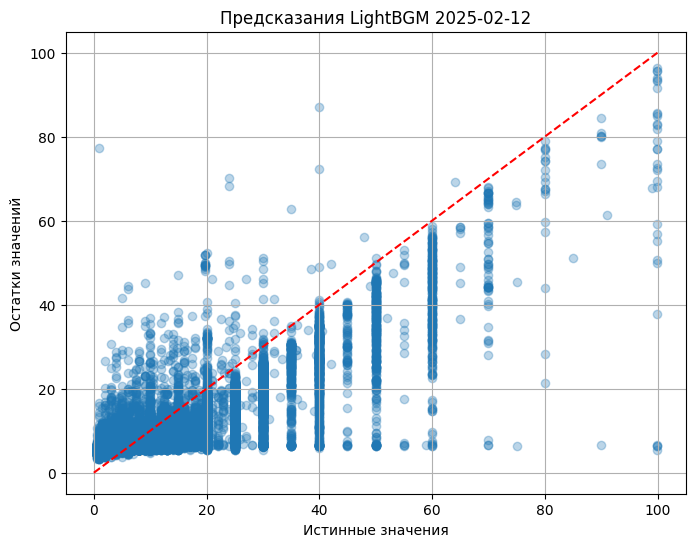

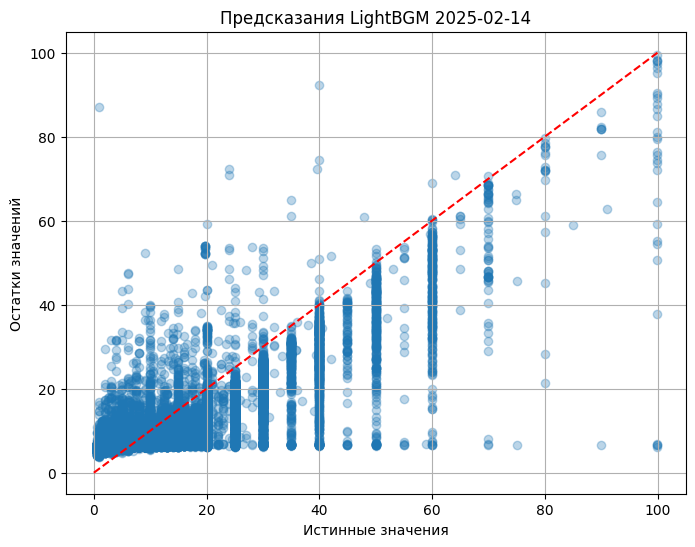

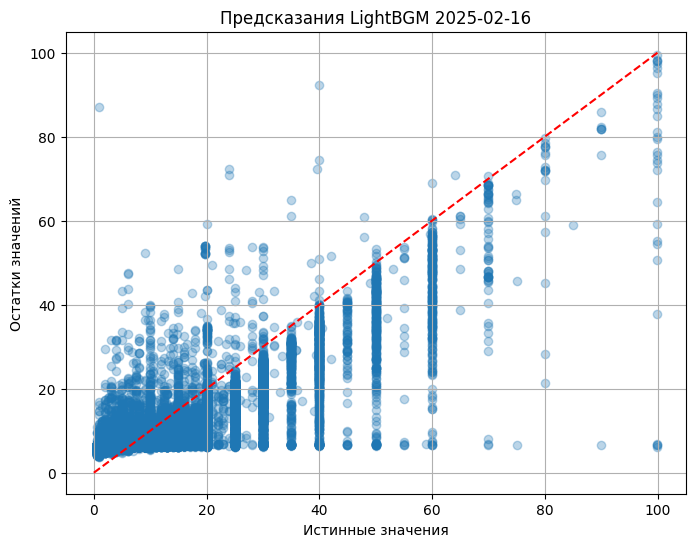

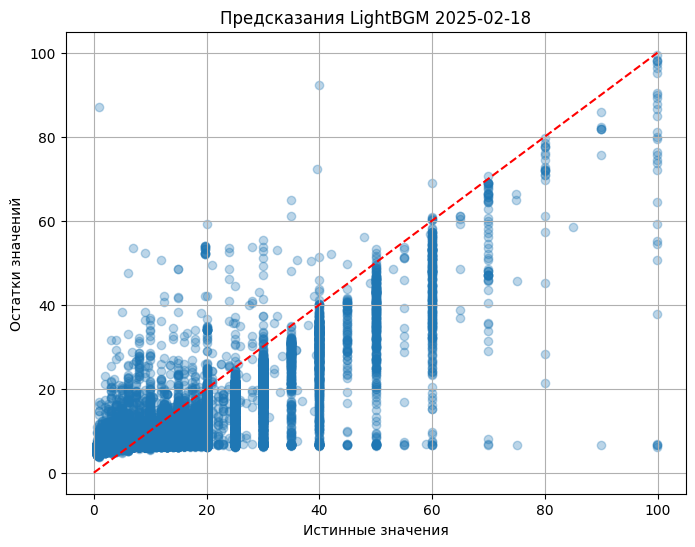

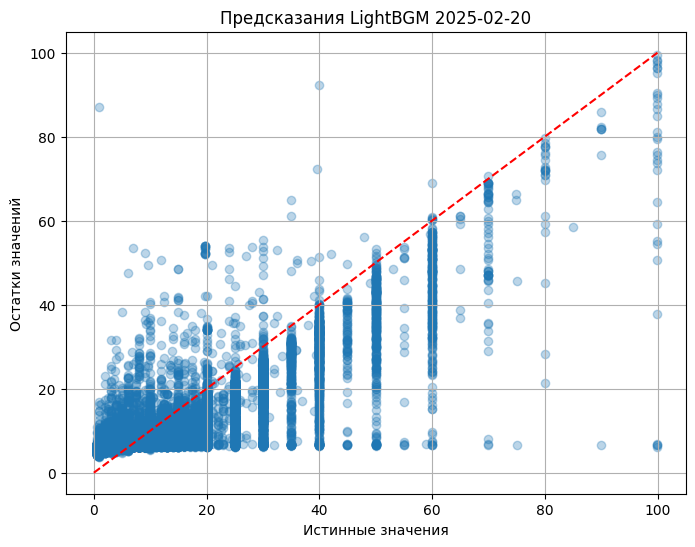

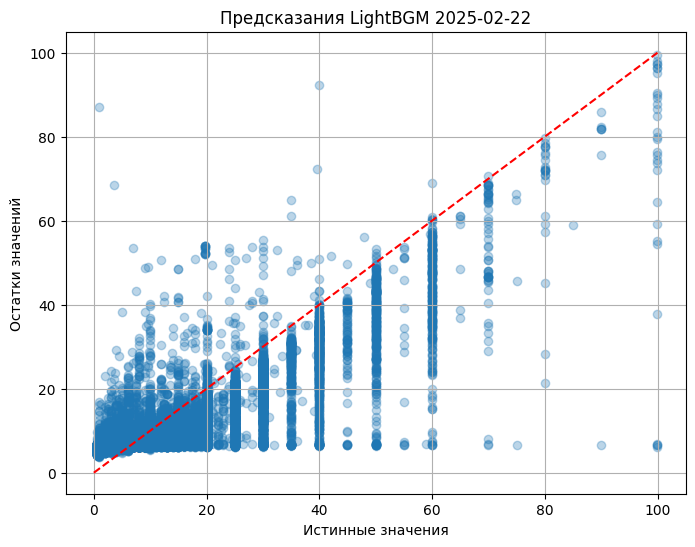

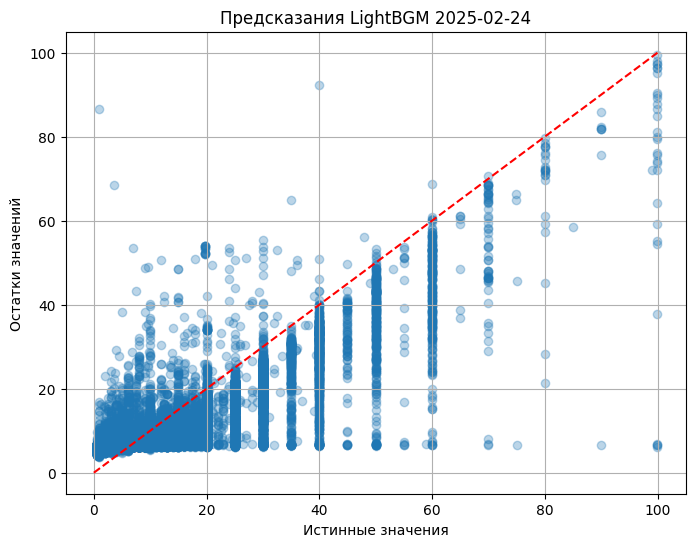

In [71]:
for _date in da[da >= test_start_date]:
    mask_border = df_test['date_acquired'] == _date

    plt.figure(figsize=(8,6))
    plt.scatter(y_true[mask_border], y_pred[mask_border], alpha=0.3)
    plt.plot([0, y_true.max()], [0, y_true.max()], 'r--')
    plt.xlabel('Истинные значения')
    plt.ylabel('Остатки значений')
    plt.title(f'Предсказания LightBGM {_date.astype('datetime64[D]')}')
    plt.grid()
    plt.show()